In [4]:
import pandas as pd

df = pd.read_csv("data/raw/D09 - winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


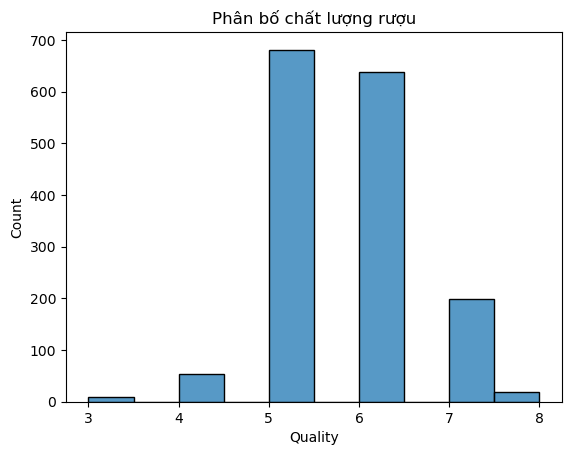

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
#Histogram
sns.histplot(df['quality'], bins=10)
plt.title("Phân bố chất lượng rượu")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

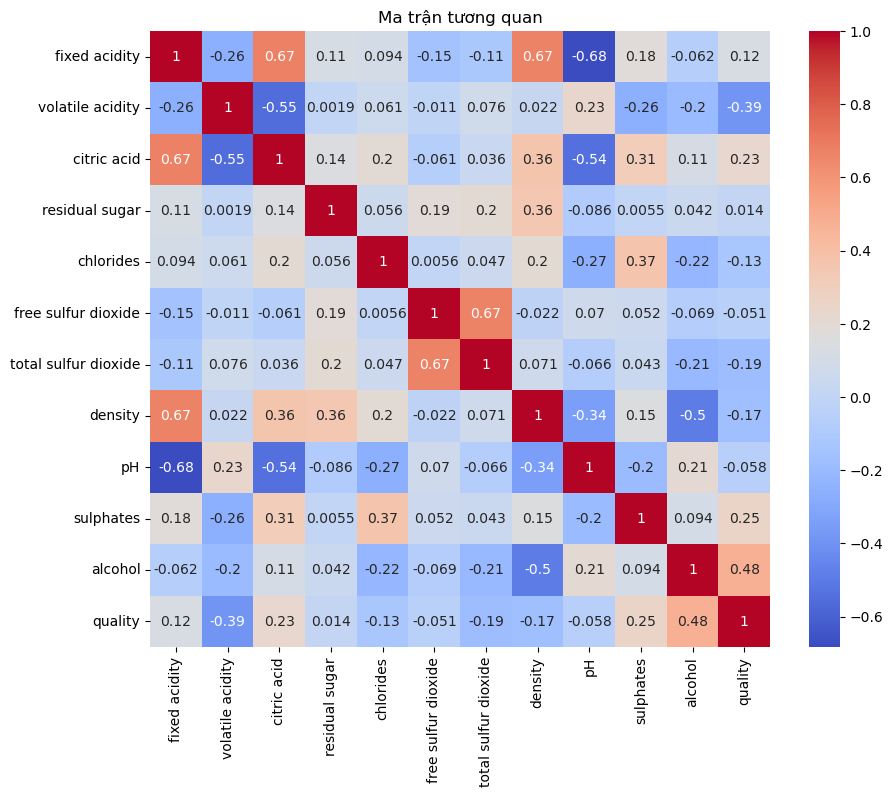

In [ ]:
#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

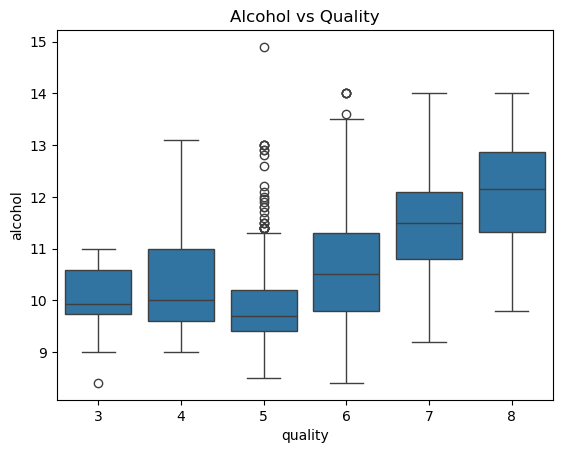

In [7]:
#Boxplot
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title("Alcohol vs Quality")
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


In [11]:
df[['quality', 'cluster']].head()

,quality,cluster
0,5,0
1,5,0
2,5,0
3,6,2
4,5,0


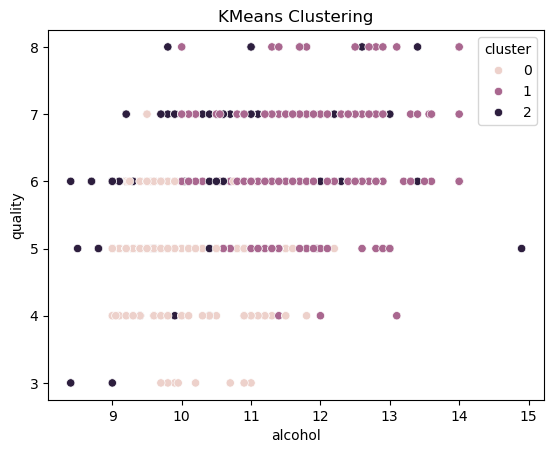

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['alcohol'], y=df['quality'], hue=df['cluster'])
plt.title("KMeans Clustering")
plt.show()

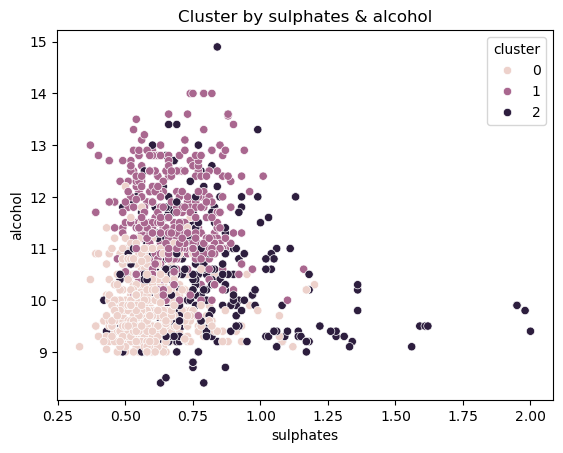

In [13]:
sns.scatterplot(x=df['sulphates'], y=df['alcohol'], hue=df['cluster'])
plt.title("Cluster by sulphates & alcohol")
plt.show()

In [14]:
df['cluster'].value_counts()

cluster
0    803
1    405
2    391
Name: count, dtype: int64

In [15]:
df.groupby('cluster').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
cluster,,,,,,,,,,,,
0,7.731258,0.619166,0.174296,2.483375,0.085093,16.897260,54.816936,0.996935,3.341046,0.592715,9.822873,5.200498
1,7.372346,0.451568,0.247951,2.292840,0.070491,17.112346,39.066667,0.994762,3.387185,0.675235,11.620041,6.261728
2,10.509207,0.419207,0.493376,2.907417,0.109923,12.493606,36.987212,0.998416,3.170844,0.774834,10.415516,5.882353


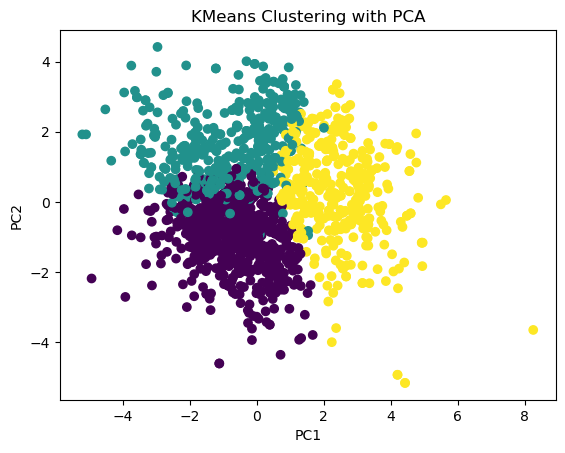

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# giảm chiều còn 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# vẽ
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("KMeans Clustering with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()